
---

# A股日内做T时序模型设计方案

## 1. 背景与目标
为了进一步降低持仓成本，计划在不改变选股名单的前提下，利用已有底仓进行**日内做T**（Intraday Trading）。

*   **核心目标：** 利用日内波动的均值回归，在合适的时间点卖出再买入（或先买后卖），降低单笔持仓成本。
*   **约束条件：** 
    1. A股T+1制度（利用老仓实现日内T+0）。
    2. 交易成本（印花税 + 佣金 + 滑点）约需 0.15%~0.2% 空间才能盈利。
    3. 每日收盘前必须复原仓位，不影响截面模型的持仓结构。

---

## 2. TWAP 与 VWAP 的“张力”
核心思路是观察 **Price (当前价)**、**VWAP (成交量加权均价)** 与 **TWAP (时间加权均价)** 之间的动态关系。

### 2.1 资金逻辑解读
*   **VWAP** 代表了当日市场成交的**平均成本中心**。
*   **TWAP** 代表了随时间流逝的**线性平衡线**。
*   **二者偏差的意义：**
    *   $VWAP > TWAP$：说明成交量集中在高位，资金在向上攻击或高位换手。
    *   $VWAP < TWAP$：说明成交量集中在低位，市场处于放量阴跌或低位恐慌砸盘。

---

## 3. 建模方案：均值回归时序模型

### 3.1 特征工程 (Features)
我们以 **10:30** 为关键观察点（此时已包含早盘约 40% 的成交量，信号较为稳固）。

| 特征分类 | 特征公式 | 业务含义 |
| :--- | :--- | :--- |
| **价格偏离 ($X_1$)** | `Price / VWAP - 1` | 当前价格相对于今日平均成本的溢价/折价（橡皮筋拉伸程度）。 |
| **能量偏离 ($X_2$)** | `VWAP / TWAP - 1` | 资金成交的价位重心。衡量早盘是“放量拉升”还是“放量砸盘”。 |
| **成交量能 ($X_3$)** | `Vol_now / Vol_avg_5d` | 当前成交量是否异常放大，作为反转的确认信号。 |
| **时间因子 ($X_4$)** | `Time_to_Close` | 离收盘的时间越近，回归 VWAP 的压力越大。 |

### 3.2 标签设计 (Label)
预测目标不再是绝对涨跌，而是**回归空间**。
*   **目标 $Y$：** `(14:50 收盘价 / 10:30 当前价) - 1`
*   **目标说明：** 寻找在 10:30 时刻，哪些股票到收盘时有最大的回升（做正T）或回落（做倒T）空间。

---

## 4. 数值案例推演
假设我们观察两只股票在 **10:30** 的表现：

### 案例 A：超跌回归（正T机会）
*   **10:30 数据：** Price = 9.80, VWAP = 10.00, TWAP = 10.10
*   **计算特征：**
    *   $X_1$ (Price偏离): $9.80 / 10.00 - 1 = -2.0\%$ （价格显著低于成本中心）
    *   $X_2$ (能量偏离): $10.00 / 10.10 - 1 = -1.0\%$ （低位放量砸盘）
*   **模型预测：** 此时“橡皮筋”拉得太紧，下午收盘前价格大概率向 VWAP 回归。
*   **结果：** 14:50 价格回升至 10.05。做T收益 = **+2.5%**（覆盖成本后盈利约 2.3%）。

### 案例 B：超涨回落（倒T机会）
*   **10:30 数据：** Price = 10.50, VWAP = 10.20, TWAP = 10.10
*   **计算特征：**
    *   $X_1$ (Price偏离): $10.50 / 10.20 - 1 = +2.9\%$ （价格远高于成本中心）
    *   $X_2$ (能量偏离): $10.20 / 10.10 - 1 = +1.0\%$ （高位放量换手）
*   **模型预测：** 情绪过热，脱离成本中枢，下午大概率回踩。
*   **结果：** 14:50 价格回落至 10.30。做T收益 = 先卖后买，降低成本约 **1.9%**。

---

## 5. 小市值股票随机测试

### 批量测试特征X1，X2 与 Y 汇总 （同时合成特征Z）
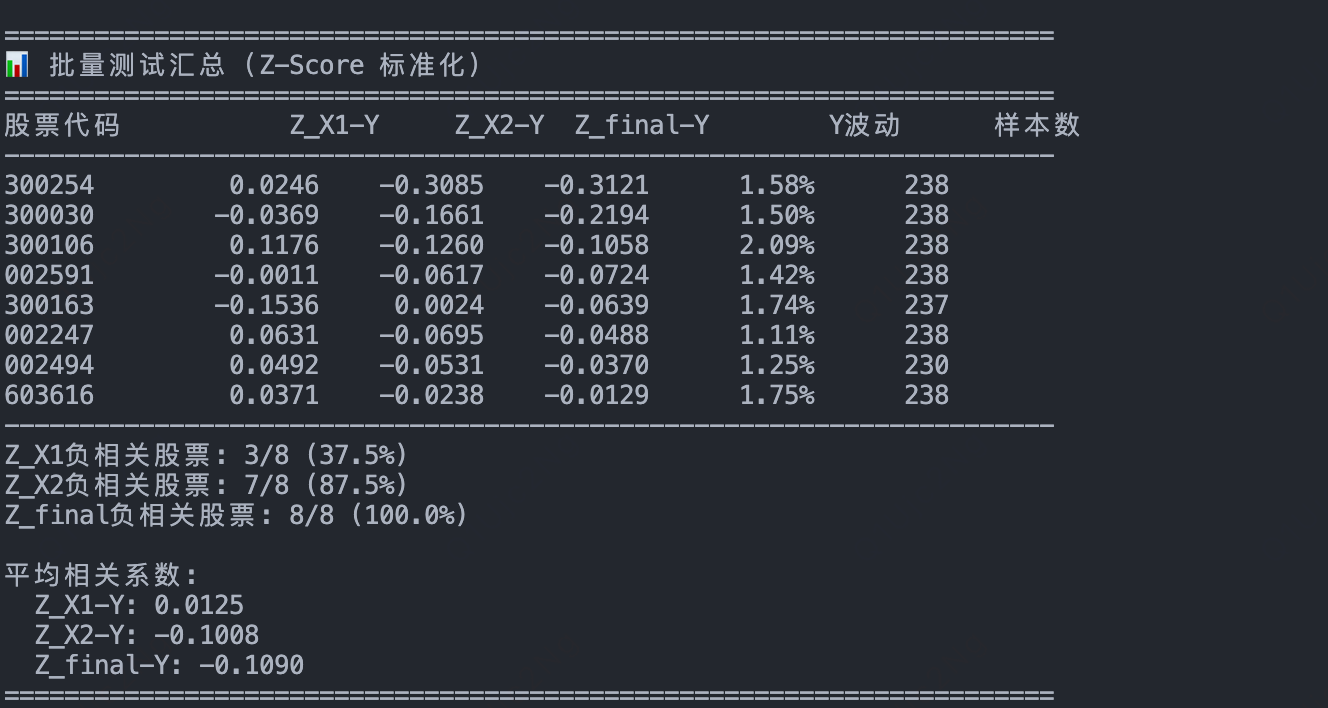

* X1 正负都有，那么X1 到底是一个动量因子还是个反转因子？
* X2 整体保持负相关，说明VWAP/TWAP 的能量偏差具有很强的回归动力

### 共振信号分析
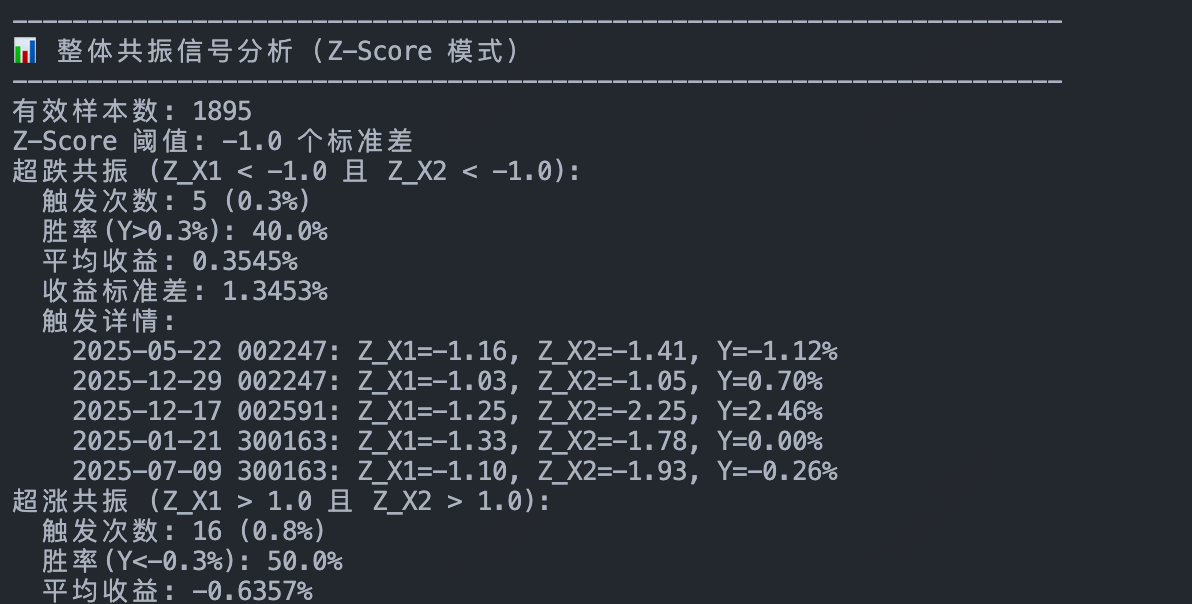

* 超涨共振信号，平均收益-0.6357%，0.63% - 0.2% = 0.43% （每笔净利润）
* 只要共振大于0.2% (印花税+佣金+滑点)，这个策略就可以赚钱
* 毛估一下策略收益：持仓标的数量：100只，100 * 1% = 1个/日，
   单日收益应该是：0.43% * 1% * 1 = 0.43bp, 年化0.43 * 240 = 103BP，年化收益是1.03%
   但如果将持仓标的的数量放大到800-1000只，大概年化收益的增益是8%-10%。

## 6. 中证2000样本 （2025年度测试）

### 批量测试特征X1，X2 与 Y 汇总 （同时合成特征Z）
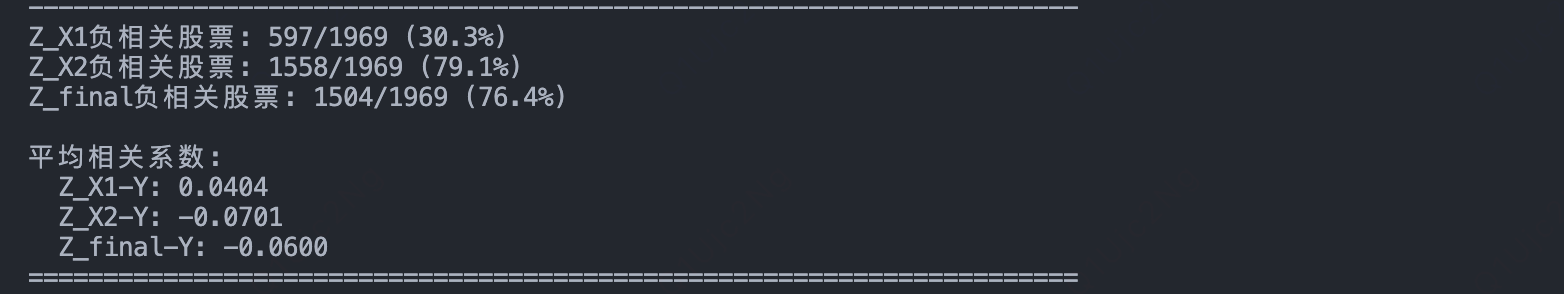

* 在大样本测试下，X1 平均相关性是4%，说明X2是一个动量因子
* X2的IC在-7%，说明X2应该是均值回归的重要锚点

### 共振信号分析
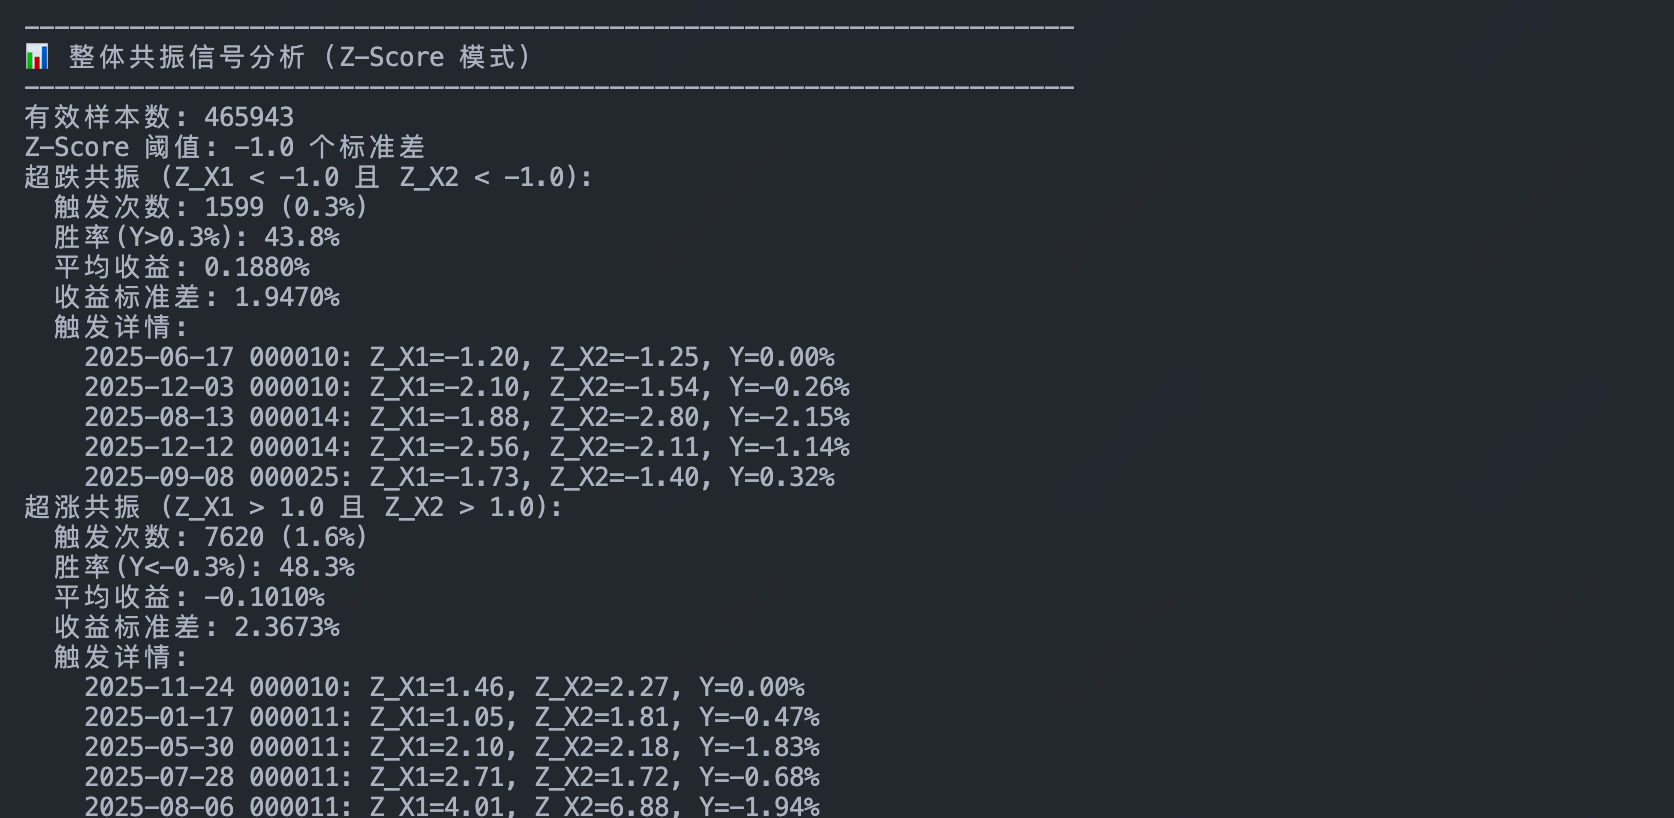

### 1.1 动态相对廉价度
*   **5分钟 VWAP ($V_{5m}$)**：代表你当下入场的即时成本。
*   **剩余时间 VWAP ($V_{rest}$)**：代表从现在起到收盘的预期平均成本。
*   **逻辑**：如果能预测出接下来的 5 分钟价格是今天剩下的时间里最便宜的（$V_{5m} < V_{rest}$），那么此时买入就是绝对正确的。

### 1.2 标签公式
$$Y_t = \frac{VWAP_{(t \to t+5min)}}{VWAP_{(t+5min \to 15:00)}}$$

### 1.3 阈值定义（三分类模型）
*   **Label = 1 (买入信号)**：当 $Y_t < 0.995$。
    *   *解释*：未来5分钟价格比剩余时间均价便宜 0.5% 以上。
*   **Label = -1 (卖出信号)**：当 $Y_t > 1.005$。
    *   *解释*：未来5分钟价格比剩余时间均价贵 0.5% 以上。
*   **Label = 0 (观望)**：波动不足以覆盖手续费。

---

### 2.1 核心定义回顾
*   **`X2_zscore` (我们的特征)**：代表“当下”的能量偏差。
    *   **数值越大(+)**：说明早盘在高位成交了巨量，现在价格可能有“虚高”泡沫。
    *   **数值越小(-)**：说明早盘在低位成交了巨量，现在价格可能有“超跌”机会。
*   **`remaining_vwap` ($V_{rest}$，我们的目标)**：代表“从现在到收盘”的平均成本。

### 2.2 从数据中探索“相关性”（举两个例子）

假设是：**“如果我现在买入，我的价格会比今天剩下的平均价便宜。”** 

#### 场景 A：超跌反弹（我们希望看到的）
*   **10:30 时刻**：某只票被恐慌性抛盘砸到了低位，成交量巨大。
*   **此时特征**：`X2_zscore` 算出是一个很大的负数（比如 **-3.0**），说明能量严重向低位倾斜。
*   **直觉**：此时的 5 分钟均价 ($V_{5m}$) 应该低于今天剩下的平均价 ($V_{rest}$)。
*   **结果**：如果下午价格真的回升了，$V_{rest}$ 变成了 10.00 元，而你买的 $V_{5m}$ 是 9.80 元。
*   **逻辑验证**：**当 `X2_zscore` 很小时，$(V_{5m} / V_{rest})$ 也应该很小（小于1）。**

#### 场景 B：超涨回落
*   **10:30 时刻**：某只票被游资快速拉升，在高位剧烈换手，成交量巨大。
*   **此时特征**：`X2_zscore` 算出是一个很大的正数（比如 **+3.0**），说明能量严重向高位倾斜。
*   **老板的直觉**：此时的 5 分钟均价 ($V_{5m}$) 应该高于今天剩下的平均价 ($V_{rest}$)。
*   **结果**：如果下午价格回落了，$V_{rest}$ 只有 10.00 元，而你卖出的 $V_{5m}$ 是 10.20 元。
*   **逻辑验证**：**当 `X2_zscore` 很大时，$(V_{5m} / V_{rest})$ 也应该很大（大于1）。**

---

### 2.3. 什么是“相关性稳定且为正”？
*注意：如果 $Y = V_{5m} / V_{rest}$，我们要找的是**正相关**（$X_2$ 越大，$Y$ 越大）。*

*   每当 `X2_zscore` 出现正极值，随后的 $V_{5m}$ 确实都比 $V_{rest}$ 高。
*   每当 `X2_zscore` 出现负极值，随后的 $V_{5m}$ 确实都比 $V_{rest}$ 低。



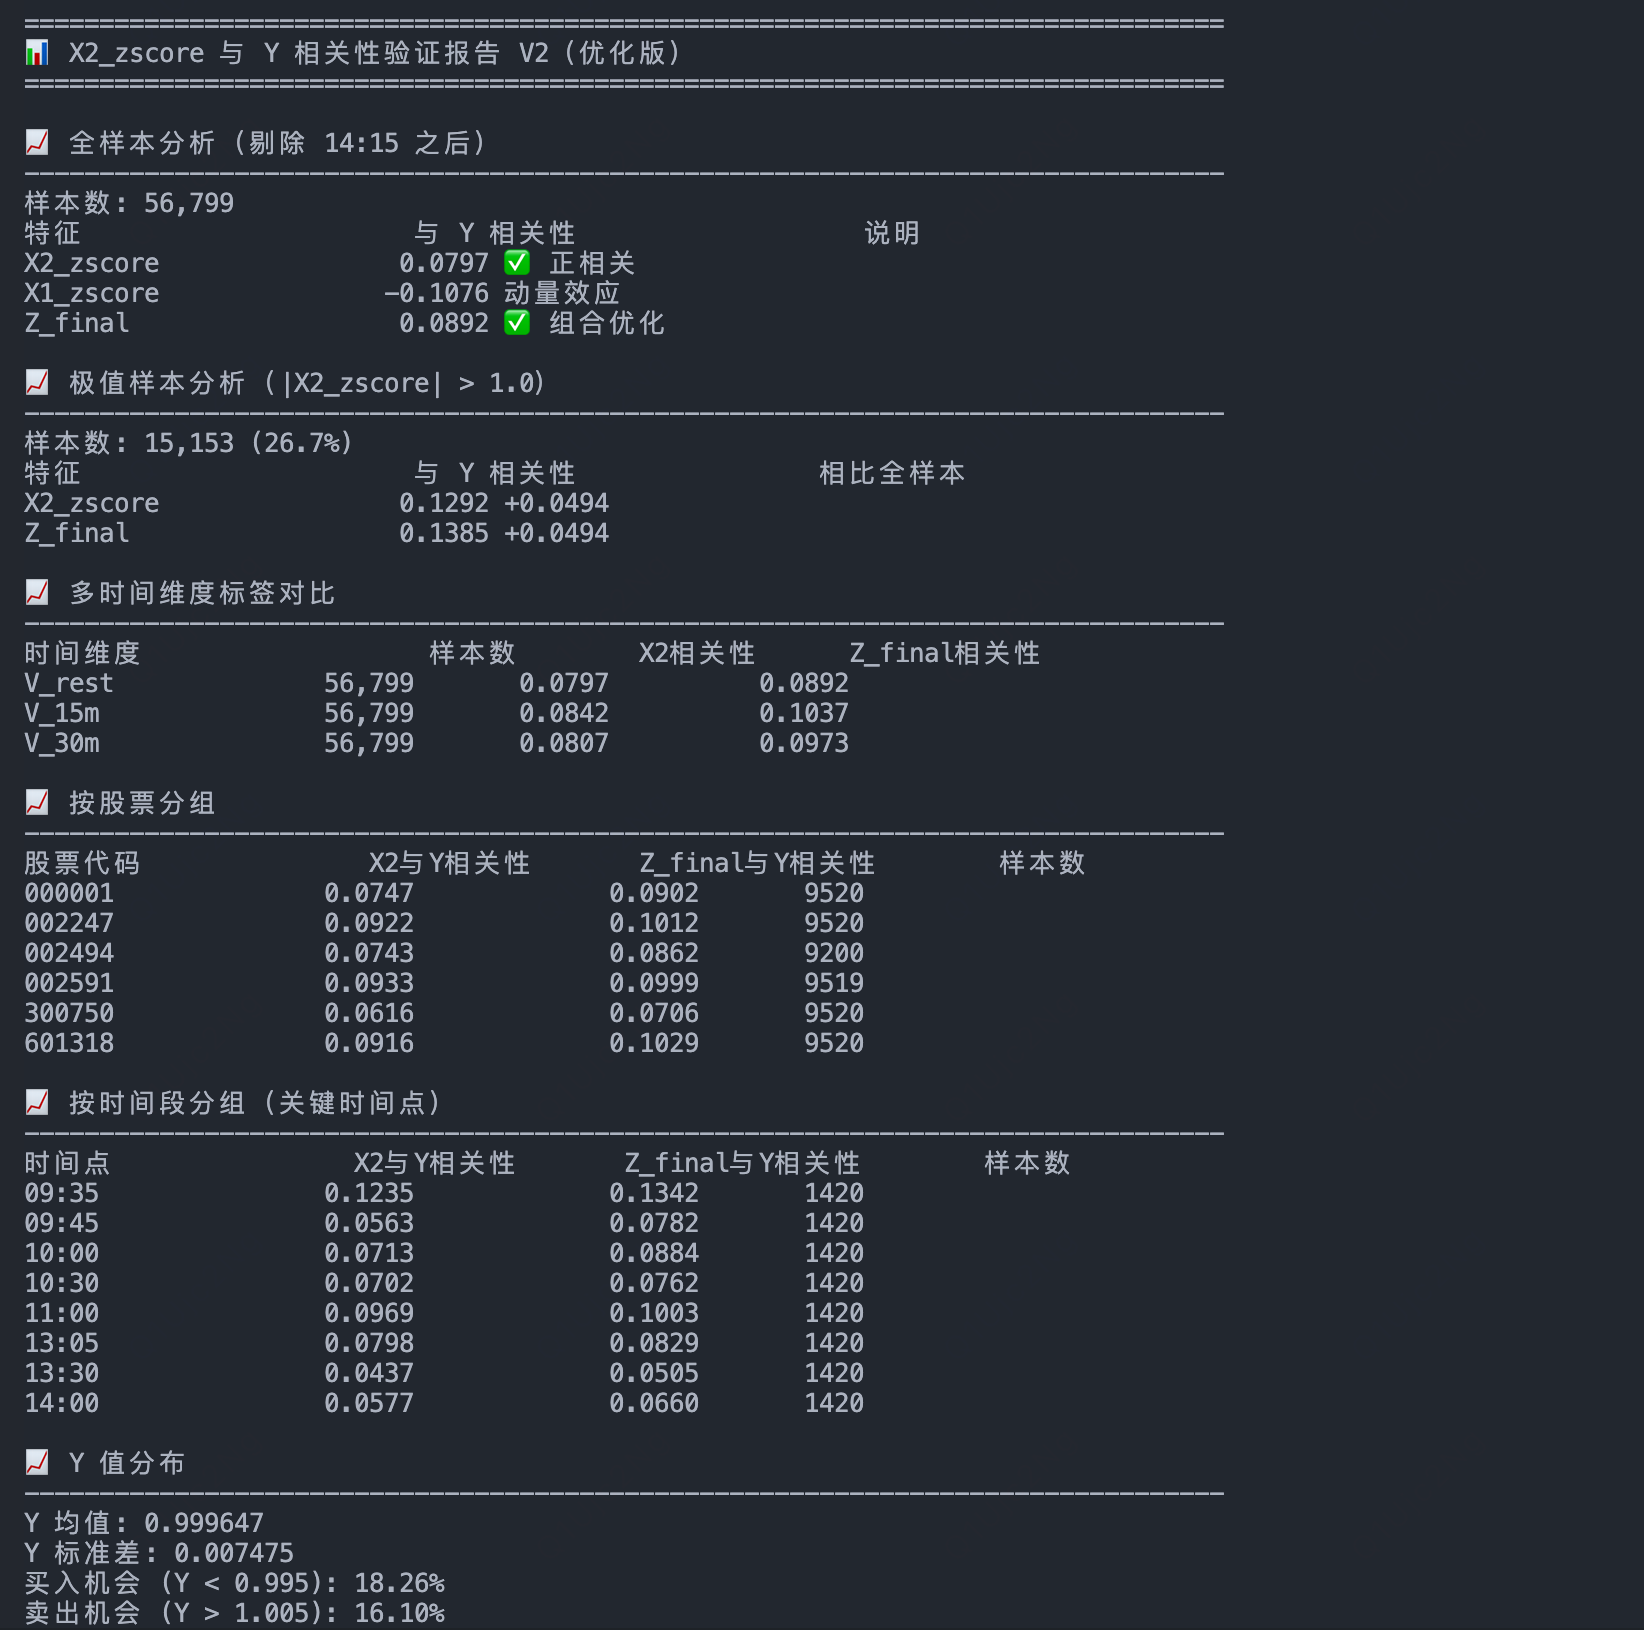

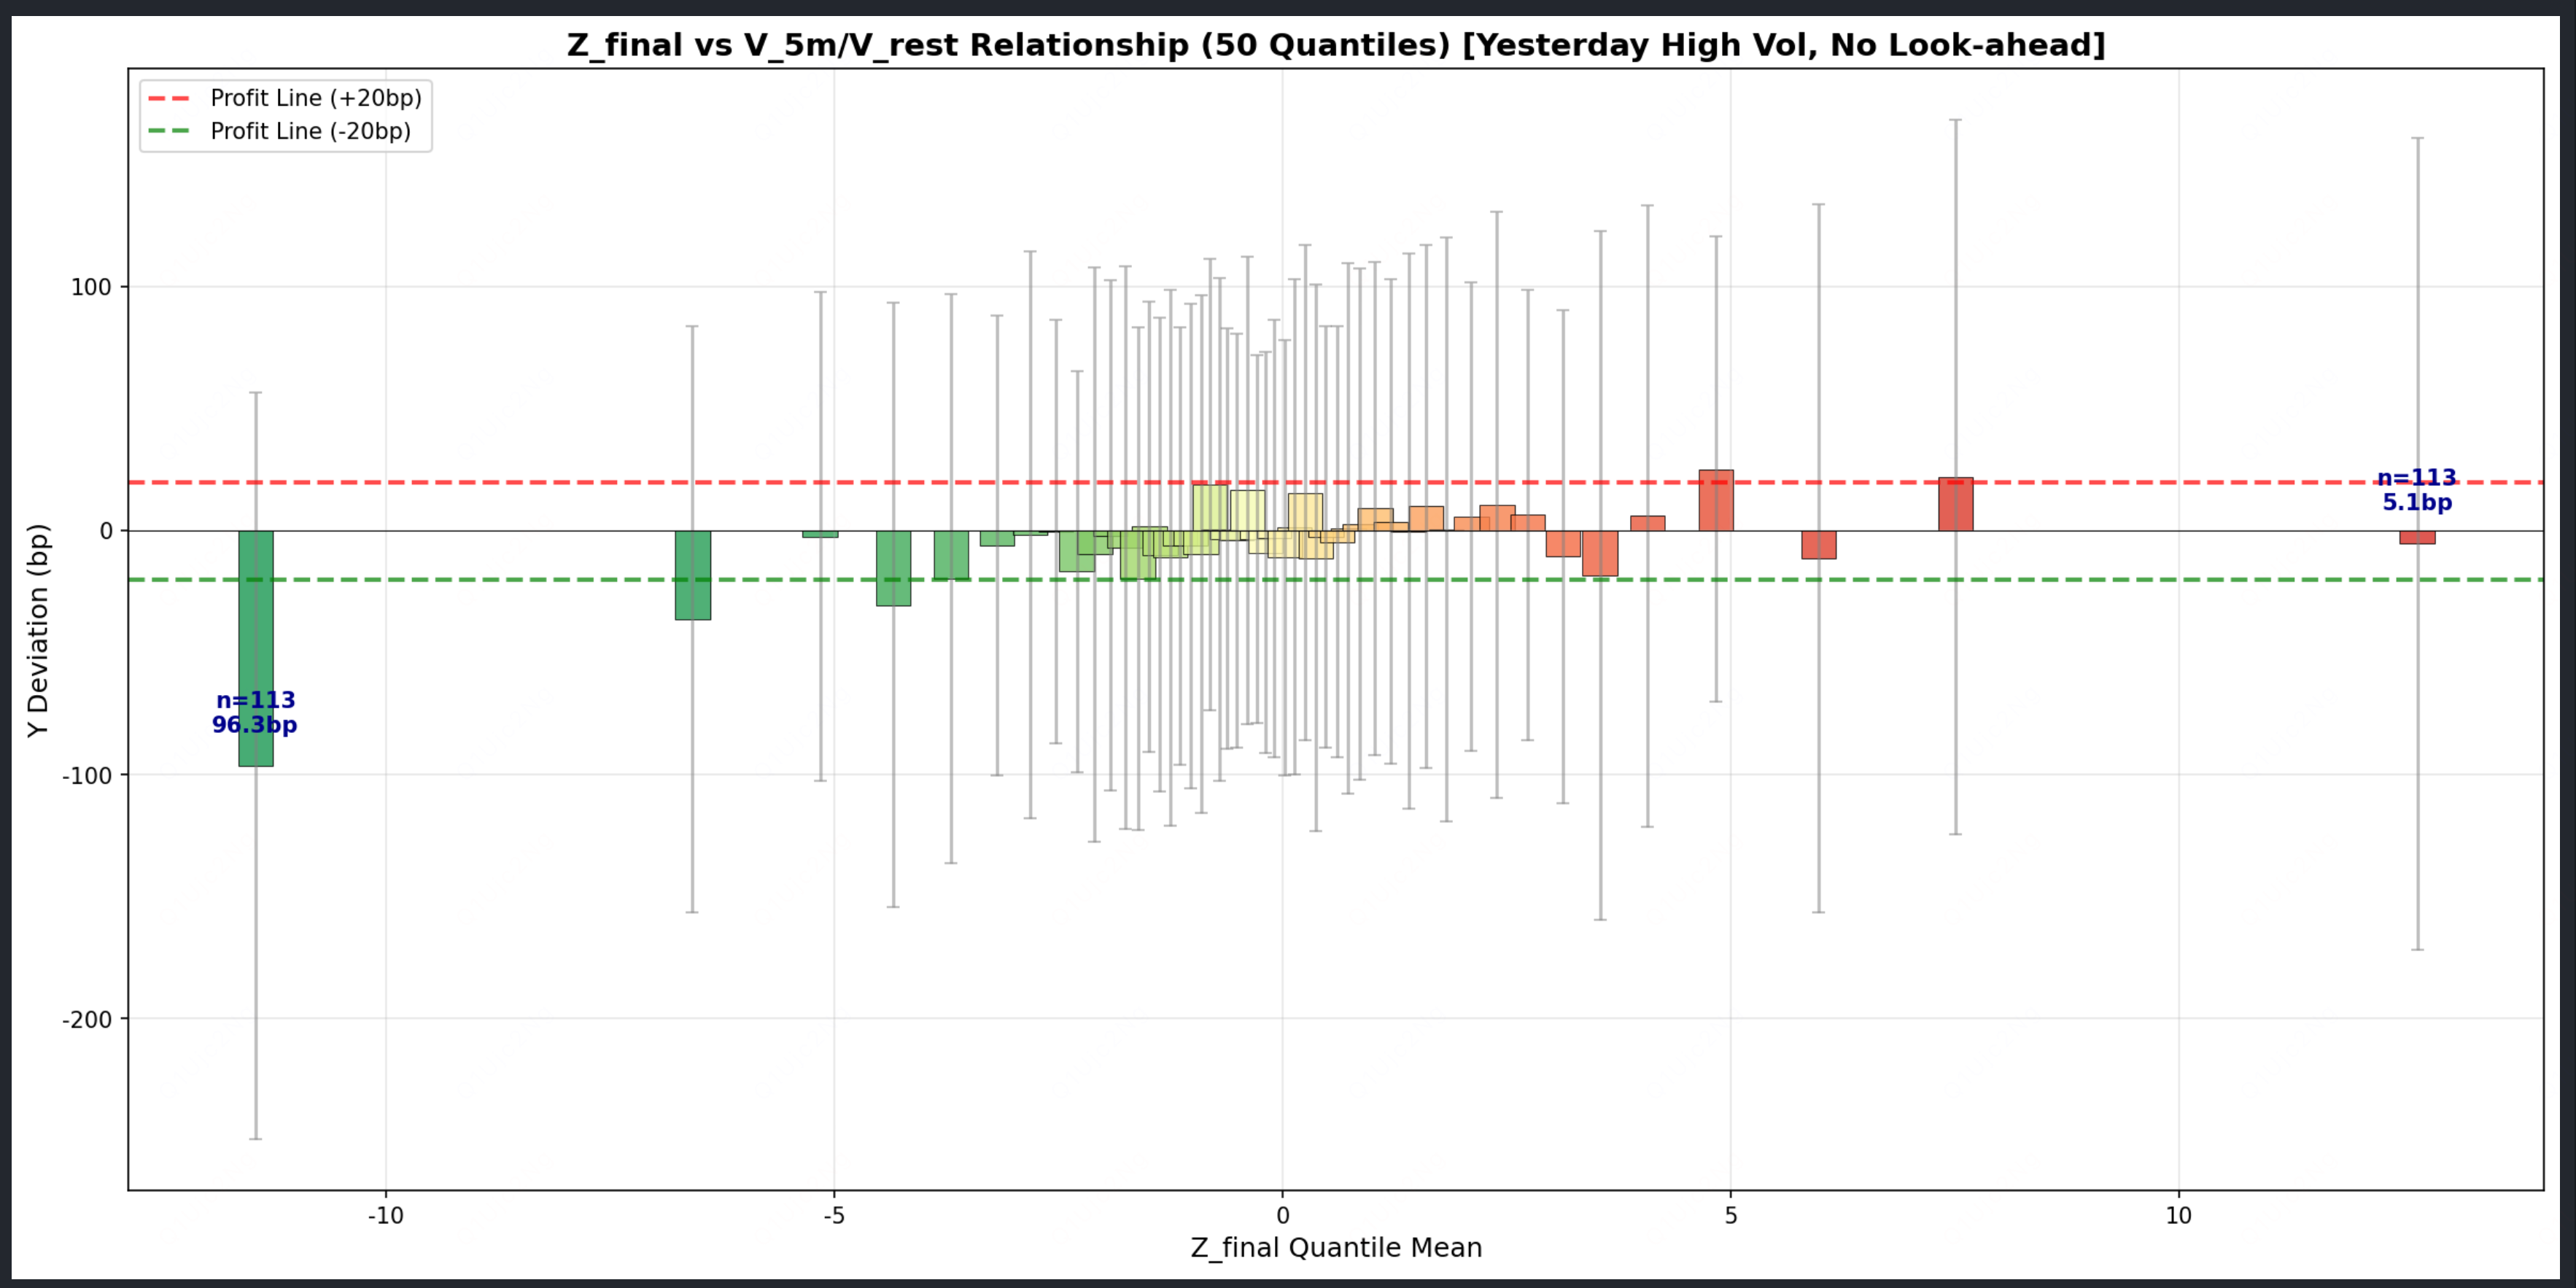

### 分析一：信号后的“回归曲线”统计 (The Edge Curve)

#### 1. 逻辑
我们想观察：信号发出后，Alpha（超额收益）是如何随时间衰减的。
*   **动作**：以信号发出时刻为 $T_0$，提取该时刻后每隔 $N$ 分钟的价格。
*   **指标**：计算 $R_t = (Price_{T_0 + t} / Price_{T_0}) - 1$。
*   **目标**：找到平均收益最高的那个时间点（比如 15 分钟处），这以后就是我们的最佳平仓位。

### 分析二：“Z值 vs 胜率” 阶梯表 (Probability Ladder)

#### 1. 逻辑
我们想量化“橡皮筋”拉多长时，胜率会发生质变。
*   **定义胜率**：在未来 30 分钟内，最高价格回升空间是否超过了 **20bp**（覆盖成本）。
*   **动作**：将 $Z_{final}$ 划分为不同的等级（比如 -1.5, -3, -5, -10）。
*   **目标**：证明“越极端，越安全”。

### 分析三：过滤器 (Filter) 的减损分析

#### 1. 逻辑
“趋势滤网（不买新高）”不是在浪费机会
*   **对比组 A**：所有满足 $Z < -1.5$ 的原始信号。
*   **对比组 B**：满足 $Z < -1.5$ 但**被滤网挡住**的信号（即：$Z$ 说买，但价格正在创新高）。
*   **动作**：计算对比组 B 在随后 30 分钟的表现。
*   **目标**：如果组 B 的收益平均为负，说明滤网“成功拦截接飞刀”。


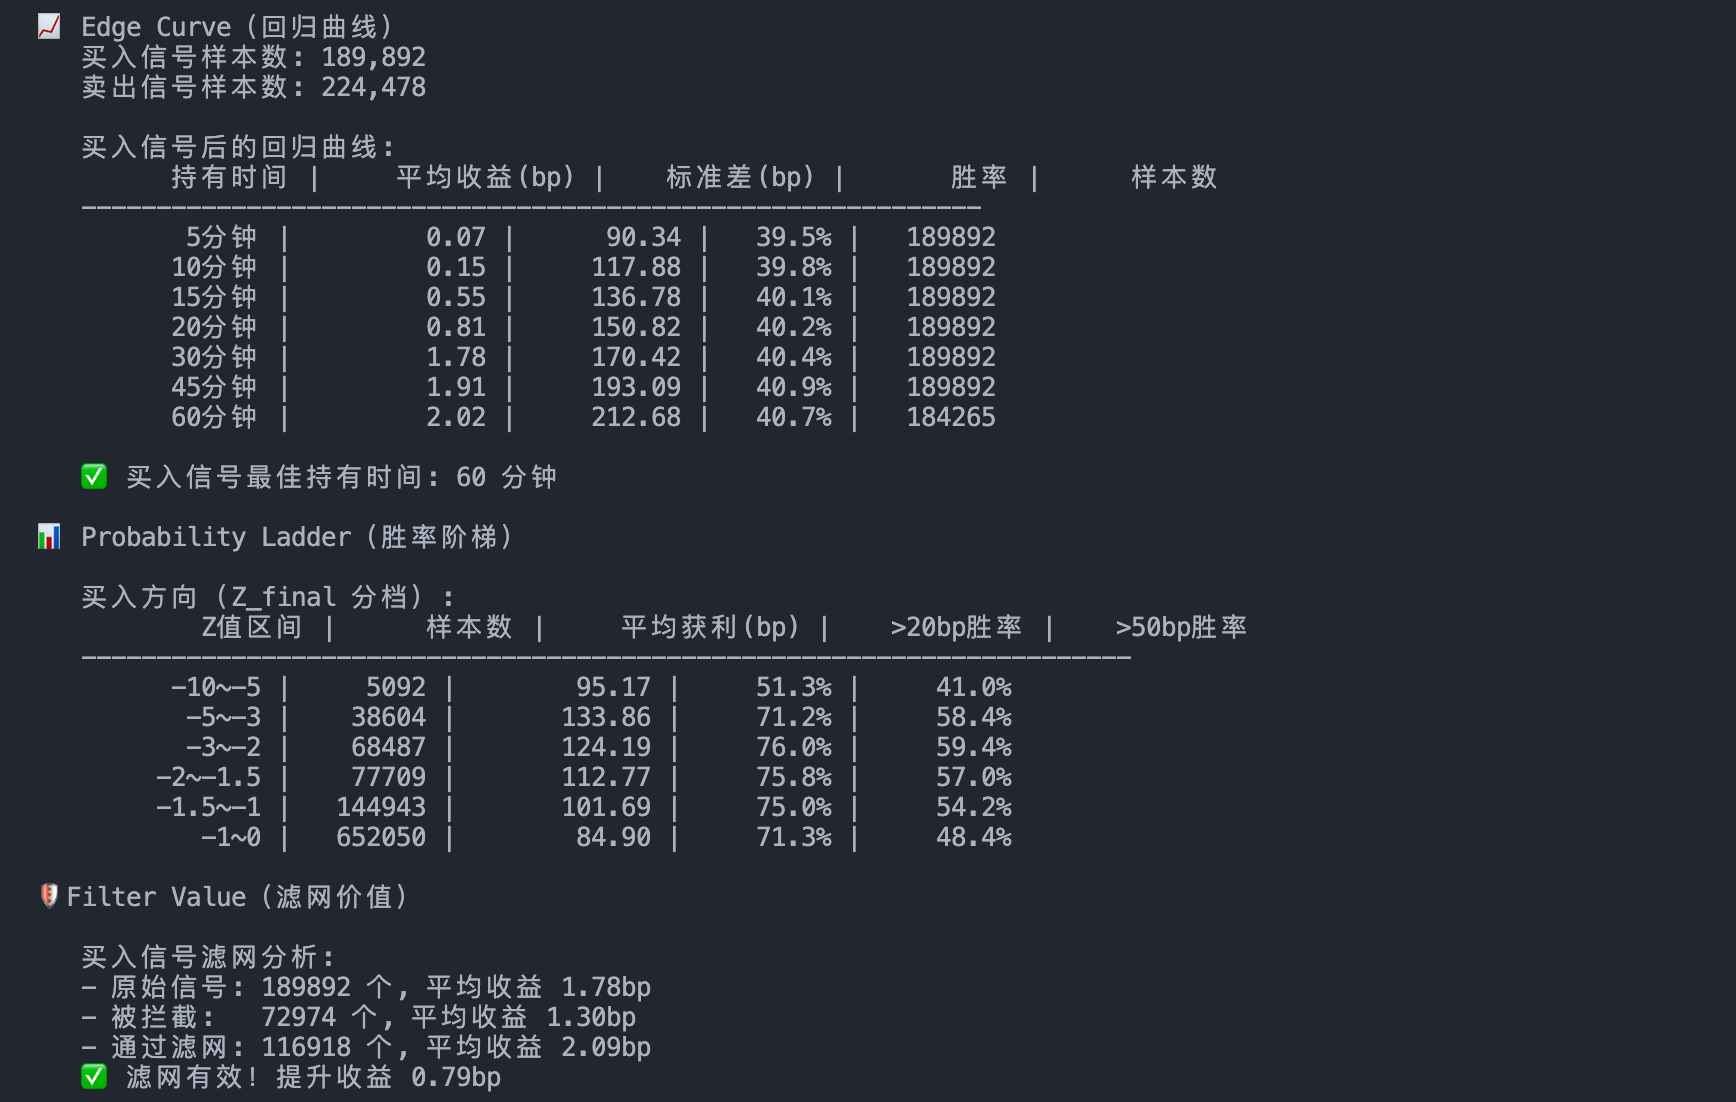